# Assignment

> Add blockquote



## Problem Statement:
Study analysis on the public sentiment towards a company and its stock effect their prices by extracting opinions from Twitter in determining whether public opinion has impact on the stock prices of the company.

In [67]:
import pandas as pd
import numpy as np
import re

SAMPLE_SIZE = 20_000
CHUNK_SIZE = 50_000
RANDOM_STATE = 42

def looks_like_date(value):
    return isinstance(value, str) and bool(re.fullmatch(r"\d{2}/\d{2}/\d{4}", value.strip()))

def looks_like_number(value):
    try:
        float(value)
        return True
    except (TypeError, ValueError):
        return False

def row_needs_repair(row):
    return pd.isna(row["Unnamed: 0"]) and looks_like_date(row["STOCK"]) and looks_like_number(row["DATE"])

def repair_chunk(chunk):
    columns = chunk.columns.tolist()
    repaired_rows = []

    for values in chunk.itertuples(index=False, name=None):
        row = dict(zip(columns, values))

        if row_needs_repair(row) and repaired_rows:
            repaired_rows[-1].update({
                "STOCK": row["TWEET"],
                "DATE": row["STOCK"],
                "LAST_PRICE": row["DATE"],
                "1_DAY_RETURN": row["LAST_PRICE"],
                "2_DAY_RETURN": row["1_DAY_RETURN"],
                "3_DAY_RETURN": row["2_DAY_RETURN"],
                "7_DAY_RETURN": row["3_DAY_RETURN"],
                "PX_VOLUME": row["7_DAY_RETURN"],
                "VOLATILITY_10D": row["PX_VOLUME"],
                "VOLATILITY_30D": row["VOLATILITY_10D"],
                "LSTM_POLARITY": row["VOLATILITY_30D"],
                "TEXTBLOB_POLARITY": row["LSTM_POLARITY"],
            })
            continue

        repaired_rows.append(row)

    repaired = pd.DataFrame(repaired_rows)
    repaired["TWEET"] = repaired["TWEET"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    repaired = repaired[repaired["TWEET"].ne("")].copy()

    numeric_columns = [
        "Unnamed: 0", "LAST_PRICE", "1_DAY_RETURN", "2_DAY_RETURN", "3_DAY_RETURN",
        "7_DAY_RETURN", "PX_VOLUME", "VOLATILITY_10D", "VOLATILITY_30D",
        "LSTM_POLARITY", "TEXTBLOB_POLARITY"
    ]

    for column in numeric_columns:
        repaired[column] = pd.to_numeric(repaired[column], errors="coerce")

    return repaired

def load_repaired_sample(path="dataset.csv", sample_size=SAMPLE_SIZE, chunk_size=CHUNK_SIZE, random_state=RANDOM_STATE):
    repaired_parts = []
    target_rows = int(sample_size * 1.25)
    total_repaired = 0
    scanned_rows = 0

    for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
        scanned_rows += len(chunk)
        repaired = repair_chunk(chunk)
        repaired_parts.append(repaired)
        total_repaired += len(repaired)

        if total_repaired >= target_rows:
            break

    df = pd.concat(repaired_parts, ignore_index=True)

    if len(df) > sample_size:
        df = df.sample(n=sample_size, random_state=random_state).reset_index(drop=True)

    return df, scanned_rows

df, scanned_rows = load_repaired_sample()

print(f"Scanned raw CSV rows: {scanned_rows:,}")
print(f"Using sample size: {len(df):,}")
print(df.head())

Scanned raw CSV rows: 50,000
Using sample size: 20,000
   Unnamed: 0                                              TWEET      STOCK  \
0     25143.0  @GoldmanSachs fire this awful person please. M...        NaN   
1     13734.0              Thanks @Apple https://t.co/XpLikBXi8F      Apple   
2     16546.0  Check out Steve Madden Gray Black Medium Tote ...       eBay   
3      1837.0  RT @nikitakhara: Thank you, @Starbucks CEO for...  Starbucks   
4     23178.0       @GaleHaroldFan @Showtime @netflix I DO. I DO        NaN   

         DATE  LAST_PRICE  1_DAY_RETURN  2_DAY_RETURN  3_DAY_RETURN  \
0         NaN         NaN           NaN           NaN           NaN   
1  31/08/2017      164.00     -0.003963     -0.006646     -0.015427   
2  31/10/2017       37.64     -0.017003     -0.022317     -0.022317   
3  01/02/2017       53.90      0.024490      0.037106      0.041187   
4         NaN         NaN           NaN           NaN           NaN   

   7_DAY_RETURN   PX_VOLUME  VOLATILITY_10D

### Basic Descriptive Statistics

In [68]:
print("Describe: ", df.describe())

Describe:           Unnamed: 0     LAST_PRICE  1_DAY_RETURN  2_DAY_RETURN  3_DAY_RETURN  \
count  17128.000000   17134.000000  17134.000000  17134.000000  1.713400e+04   
mean   14643.158804     440.924829      0.002463      0.002702  2.159780e+06   
std     8440.355513    4420.668450      0.021628      0.027840  7.900501e+06   
min        0.000000      -0.173554     -0.177851     -0.204959 -1.778512e-01   
25%     7360.750000      33.570000     -0.005570     -0.010170 -6.222514e-03   
50%    14654.500000      51.338300      0.000792      0.002322  4.609023e-03   
75%    21968.750000     152.200000      0.007330      0.011411  2.136349e-02   
max    29276.000000  165500.000000      0.146982      0.146982  3.081068e+08   

       7_DAY_RETURN     PX_VOLUME  VOLATILITY_10D  VOLATILITY_30D  \
count  17134.000000  1.713400e+04    17134.000000    17127.000000   
mean       6.748173  7.472296e+06       16.659953       16.568149   
std       16.836424  1.073212e+07       13.507625       10.80

In [69]:
df.isnull().sum()

Unnamed: 0           2872
TWEET                   0
STOCK                2866
DATE                 2866
LAST_PRICE           2866
1_DAY_RETURN         2866
2_DAY_RETURN         2866
3_DAY_RETURN         2866
7_DAY_RETURN         2866
PX_VOLUME            2866
VOLATILITY_10D       2866
VOLATILITY_30D       2873
LSTM_POLARITY        5738
TEXTBLOB_POLARITY    5739
dtype: int64

In [70]:
df = df.dropna(subset="TWEET")
df.isnull().sum()

Unnamed: 0           2872
TWEET                   0
STOCK                2866
DATE                 2866
LAST_PRICE           2866
1_DAY_RETURN         2866
2_DAY_RETURN         2866
3_DAY_RETURN         2866
7_DAY_RETURN         2866
PX_VOLUME            2866
VOLATILITY_10D       2866
VOLATILITY_30D       2873
LSTM_POLARITY        5738
TEXTBLOB_POLARITY    5739
dtype: int64

In [71]:
print(df['LSTM_POLARITY'].unique())
print(df['TEXTBLOB_POLARITY'].unique())

[nan  1. -1.]
[            nan  2.00000000e-01 -8.33333333e-02  1.00000000e+00
  0.00000000e+00  1.00000000e-01 -7.69230769e-02  2.12121212e-01
 -7.50000000e-01  4.00000000e-01 -1.19047619e-02  5.00000000e-02
 -5.00000000e-01  8.00000000e-02 -1.66666667e-01 -1.50000000e-01
  1.66666667e-01  3.12500000e-01  6.00000000e-01  5.00000000e-01
  4.50000000e-01  1.68750000e-01 -1.00000000e-01  3.75000000e-01
  6.66666667e-02 -7.14285714e-02 -3.00000000e-01 -6.00000000e-01
  1.25000000e-01 -7.50000000e-02  2.66335227e-01  9.94318182e-02
  4.68750000e-01  3.50000000e-01  1.50000000e-01  3.08333333e-01
 -4.00000000e-01  2.50000000e-01 -7.00000000e-01  1.36363636e-01
 -2.00000000e-01  1.56250000e-01  8.00000000e-01  2.85714286e-01
 -1.25000000e-01  4.00000000e-01  2.89583333e-01 -7.14285714e-01
  5.56250000e-01  6.37500000e-01  4.33333333e-01  2.16666667e-01
 -5.00000000e-02  1.70454545e-01  7.00000000e-01  6.81818182e-02
  3.44444444e-01  3.00000000e-01 -5.35714286e-02  2.04761905e-01
  2.4375000

In [72]:
lstm_counts = df['LSTM_POLARITY'].value_counts()
textblob_counts = df['TEXTBLOB_POLARITY'].value_counts()

print("LSTM Distribution:\n", lstm_counts)
print("\nTextBlob Distribution:\n", textblob_counts)

LSTM Distribution:
 LSTM_POLARITY
 1.0    7736
-1.0    6526
Name: count, dtype: int64

TextBlob Distribution:
 TEXTBLOB_POLARITY
 0.000000    7463
 0.500000     489
 0.200000     324
 0.136364     262
 1.000000     252
             ... 
 0.106667       1
 0.556250       1
-0.231818       1
 0.344444       1
-0.078125       1
Name: count, Length: 759, dtype: int64


In [73]:
import sys
print(sys.executable)

c:\Users\hafiz\AppData\Local\Programs\Python\Python313\python.exe


In [74]:
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


LSTM_sentiment
Positive    7736
Negative    6526
Neutral     5738
Name: count, dtype: int64


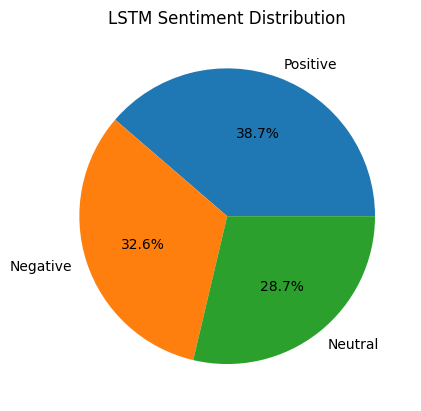

In [75]:
def categorize_lstm(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['LSTM_sentiment'] = df['LSTM_POLARITY'].apply(categorize_lstm)

lstm_counts = df['LSTM_sentiment'].value_counts()
print(lstm_counts)

import matplotlib.pyplot as plt

plt.figure()
plt.pie(lstm_counts, labels=lstm_counts.index, autopct='%1.1f%%')
plt.title("LSTM Sentiment Distribution")
plt.show()

### Metada Analysis

In [76]:
#if sentiment analysis has more neutral than +ve & -ve, there is issue in dataset
print(df.columns)
print(df['STOCK'].value_counts())


Index(['Unnamed: 0', 'TWEET', 'STOCK', 'DATE', 'LAST_PRICE', '1_DAY_RETURN',
       '2_DAY_RETURN', '3_DAY_RETURN', '7_DAY_RETURN', 'PX_VOLUME',
       'VOLATILITY_10D', 'VOLATILITY_30D', 'LSTM_POLARITY',
       'TEXTBLOB_POLARITY', 'LSTM_sentiment'],
      dtype='object')
STOCK
eBay          2669
Reuters       1764
Netflix       1274
Amazon        1055
McDonald's     627
              ... 
554.5            1
178.75           1
70.04            1
124.39           1
355.98           1
Name: count, Length: 396, dtype: int64


In [77]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['cleaned_tweet'] = df['TWEET'].apply(clean_text)

In [78]:
!{sys.executable} -m pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
### Remove Stopword
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return words

all_words = []

for tweet in df['TWEET']:
    all_words.extend(clean_text(tweet))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [80]:
word_counts = Counter(all_words)
top_words = word_counts.most_common(15)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

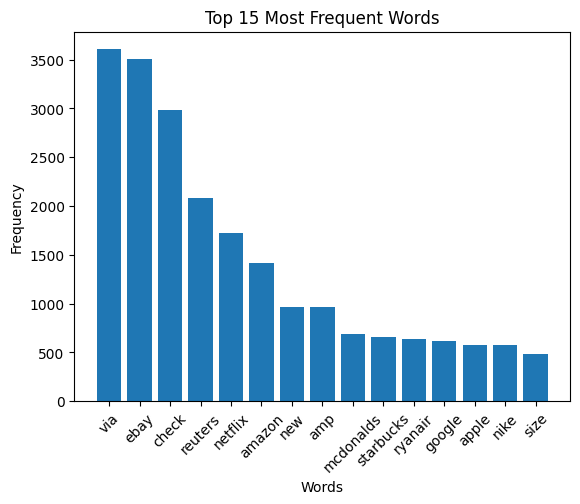

In [81]:
### Plotting
import matplotlib.pyplot as plt

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [82]:
!pip install textblob


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
from textblob import TextBlob

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df['calculated_polarity'] = df['TWEET'].apply(get_polarity)

In [84]:
def categorize_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['calculated_polarity'].apply(categorize_sentiment)

In [85]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
Neutral     10705
Positive     6442
Negative     2853
Name: count, dtype: int64


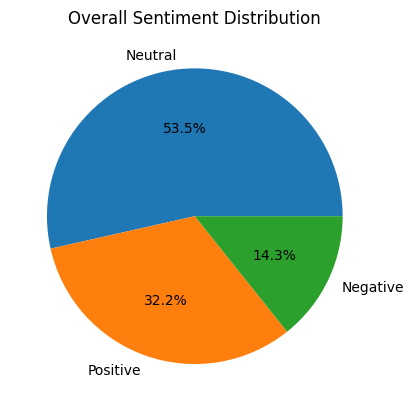

In [86]:
plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Overall Sentiment Distribution")
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


vader_sentiment
Neutral     9567
Positive    7164
Negative    3269
Name: count, dtype: int64


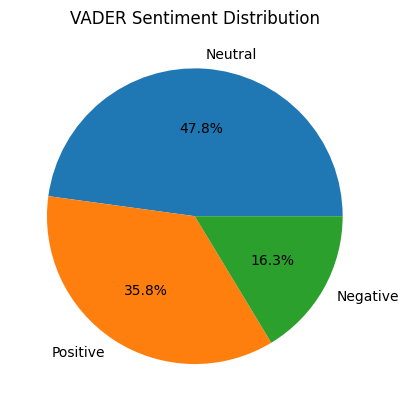

In [87]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['vader_sentiment'] = df['TWEET'].apply(get_sentiment)

vader_counts = df['vader_sentiment'].value_counts()
print(vader_counts)

import matplotlib.pyplot as plt

plt.figure()
plt.pie(vader_counts, labels=vader_counts.index, autopct='%1.1f%%')
plt.title("VADER Sentiment Distribution")
plt.show()

### Preprocessing Pipeline

#### Sentence Segmentation

In [88]:
import nltk

from nltk.tokenize import sent_tokenize

# Download the required NLTK resources
nltk.download('punkt')      # Rules for tokenization (chopping text)
nltk.download('punkt_tab')  # NEW requirement for tokenization in updated NLTK versions
nltk.download('stopwords')  # List of common, uninformative words
nltk.download('wordnet')    # Massive English dictionary for Lemmatization
nltk.download('omw-1.4')    # Supporting data for WordNet

print("NLTK Resources Downloaded Successfully!")


NLTK Resources Downloaded Successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [89]:

# Sentence Segmentation
df["sentences"] = df["TWEET"].apply(sent_tokenize)



In [90]:
for i, s in enumerate(df["sentences"].iloc[194]):
    print(f"Sentence {i+1}: {s}")

Sentence 1: RT @QLIRehab: And HUGE congratulations to our friends at @FusionMedStaff1, @Linkedin, and @Yahoo for their well-deserved awards.
Sentence 2: https://t…


#### Handling Abbreviations

In [91]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [92]:
# Abbreviation Dictionary
abbreviation_dict = {
    "rt": "retweet",
    "roi": "return on investment",
    "vix": "volatility index",
    "u": "you",
    "ur": "your",
    "w/": "with",
    "dm": "direct message",
    "fb": "facebook",
    "ig": "instagram",
    "li": "linkedin",
    "yt": "youtube",
    "omg": "oh my god",
    "lol": "laugh out loud"
}

#### Tokenization

In [93]:
def tokenize_and_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    tokens = word_tokenize(text)

    expanded_tokens = []
    for word in tokens:
        expanded_word = abbreviation_dict.get(word, word)
        expanded_tokens.extend(expanded_word.split())

    clean_tokens = [word for word in expanded_tokens if word.isalpha()]
    return clean_tokens

In [94]:
def expand_abbreviations(token_list):
  expanded_tokens = []
  for word in token_list:
    # if word in dict, replace it
    expanded_word = abbreviation_dict.get(word.lower(), word)
    expanded_tokens.append(expanded_word.split())
  return expanded_tokens

df["tokens"] = df["TWEET"].apply(tokenize_and_clean)
df["expanded_tokens"] = df["tokens"].apply(expand_abbreviations)

In [95]:
df['expanded_tokens']

0        [[goldmansachs], [fire], [this], [awful], [per...
1                                      [[thanks], [apple]]
2        [[check], [out], [steve], [madden], [gray], [b...
3        [[retweet], [nikitakhara], [thank], [you], [st...
4        [[galeharoldfan], [showtime], [netflix], [i], ...
                               ...                        
19995    [[retweet], [i], [did], [realise], [a], [new],...
19996    [[retweet], [drops], [yo], [fuck], [you], [mcd...
19997    [[check], [out], [wavy], [wire], [wrapped], [b...
19998    [[dear], [drew], [by], [drew], [barrymore], [d...
19999                                                   []
Name: expanded_tokens, Length: 20000, dtype: object

#### Stopword Removal

In [96]:
from nltk.corpus import stopwords

# Load the English stopwords list
stop_words = set(stopwords.words('english'))

# We can also add custom stopwords specific to our dataset if we want
custom_stopwords = ['next', 'via', 'amp']
stop_words.update(custom_stopwords)

def remove_stopwords(token_list):
    # Keep the word ONLY if it is not in our stop_words list
    filtered_tokens = [word for word in token_list if word not in stop_words]
    return filtered_tokens

# Apply to our tokens
df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

# Compare the tokens before and after stopword removal
df[['tokens', 'filtered_tokens']].head()

,tokens,filtered_tokens
0,"[goldmansachs, fire, this, awful, person, plea...","[goldmansachs, fire, awful, person, please, ma..."
1,"[thanks, apple]","[thanks, apple]"
2,"[check, out, steve, madden, gray, black, mediu...","[check, steve, madden, gray, black, medium, to..."
3,"[retweet, nikitakhara, thank, you, starbucks, ...","[retweet, nikitakhara, thank, starbucks, ceo, ..."
4,"[galeharoldfan, showtime, netflix, i, do, i, do]","[galeharoldfan, showtime, netflix]"


#### Stemming or Lemmatization

In [97]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Initialize our two tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(token_list):
    return [stemmer.stem(word) for word in token_list]

def apply_lemmatization(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

# Create two new columns to compare the results
df['stemmed_words'] = df['filtered_tokens'].apply(apply_stemming)
df['lemmatized_words'] = df['filtered_tokens'].apply(apply_lemmatization)

print("Stemming and Lemmatization complete!")

Stemming and Lemmatization complete!


#### POS Tagging

In [98]:
nltk.download('averaged_perceptron_tagger_eng')


#apply pos tag
df['pos_tags'] = df['lemmatized_words'].apply(nltk.pos_tag)



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Named Entity Recognition (NER)

In [ ]:
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

def apply_ner(tagged_tokens):
  return nltk.ne_chunk(tagged_tokens)

df['ner'] = df['pos_tags'].apply(apply_ner)

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


#### Word Cloud Visualization

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_clean_words = []
for word_list in df['lemmatized_words']:
    all_clean_words.extend(word_list)

text_for_cloud = " ".join(all_clean_words)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='inferno',
                      max_words=100).generate(text_for_cloud)

# Plot the image
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the grid numbers
plt.title("Stock Market Tweets Word Cloud", fontsize=20, fontweight='bold')
plt.show()

pipeline comparison

In [ ]:
# Select a random row (e.g., row index 5) to inspect
row_to_inspect = 200

print("1. ORIGINAL TEXT:")
print(df['TWEET'].iloc[row_to_inspect])
print("\n2. TOKENIZED & NOISE REMOVED:")
print(df['tokens'].iloc[row_to_inspect])
print("\n3. STOPWORDS REMOVED:")
print(df['filtered_tokens'].iloc[row_to_inspect])
print("\n4. STEMMED (Chopped endings):")
print(df['stemmed_words'].iloc[row_to_inspect])
print("\n5. LEMMATIZED (Dictionary root):")
print(df['lemmatized_words'].iloc[row_to_inspect])